# Ch 5 - Support Vector Machines

In this notebook I explore examples both from Chapter 5 as well as some expanded areas to really drive in understanding for myself.

#### Important Areas
* Large margin classification
* Implementing linear and nonlinear SVMs
* Kernels and hyperparameters

In [ ]:
# imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_moons
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import LinearSVC, SVC, LinearSVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2)

svm_clf = make_pipeline(StandardScaler(), LinearSVC(C=1, random_state = 42))
svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, random_state=42))])

In [ ]:
# Model is used here to make predictions based on X and Y values inputted ex [5.5, 1.7]

X_new = [[5.5, 1.7], [5.0, 1.5], [5.3, 1.6]]
svm_clf.predict(X_new)

array([ True, False,  True])

In [ ]:
svm_clf.decision_function(X_new)

array([ 0.66163816, -0.22035761,  0.26389467])

## Soft Margin Classification

Real world data is often not easily separable. Soft margin SVM allows a minor amount of margin violations controlled by the hyperparameter C.

A small C allows more violations (essentially strong regularization), while a large C punishes violations heavily, leading to tighter decision boundaries.


In [ ]:
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)
polynomial_svm_clf = make_pipeline(
 PolynomialFeatures(degree=3),
 StandardScaler(),
 LinearSVC(C=10, max_iter=10_000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, max_iter=10000, random_state=42))])

In [ ]:
poly_kernel_svm_clf = make_pipeline(StandardScaler(),
 SVC(kernel="poly", degree=3, coef0=1, C=5))
poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=5, coef0=1, kernel='poly'))])

In [ ]:
rbf_kernel_svm_clf = make_pipeline(StandardScaler(),
 SVC(kernel="rbf", gamma=5, C=0.001))
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.001, gamma=5))])

This visualization shows how SVM separates classes and maximizes margin.

In [ ]:
def plot_decision_boundary(model, X, y):
    x0s = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
    x1s = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_grid = np.c_[x0.ravel(), x1.ravel()]
    y_pred = model.predict(X_grid).reshape(x0.shape)

    plt.contour(x0, x1, y_pred, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors="k")

# C Visualization Effects

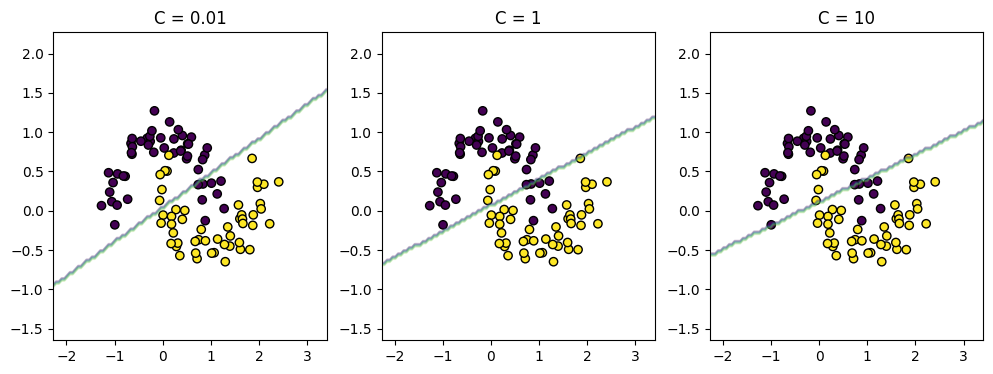

In [ ]:
C_values = [0.01, 1, 10]

X_moons, y_moons = make_moons(n_samples=100, noise=0.15, random_state=42)

plt.figure(figsize=(12,4))
for i, C in enumerate(C_values):
    model = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C))
    model.fit(X_moons, y_moons)
    plt.subplot(1,3,i+1)
    plot_decision_boundary(model, X_moons, y_moons)
    plt.title(f"C = {C}")
plt.show()

# Support Vectors Visualization

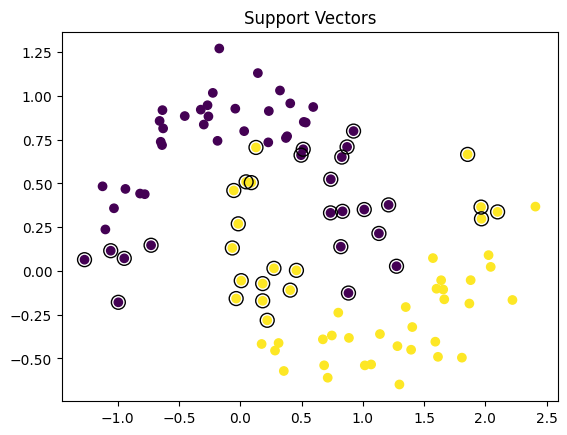

In [ ]:
svm = SVC(kernel="linear", C=1)
svm.fit(X_moons, y_moons)

plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons)
plt.scatter(svm.support_vectors_[:,0],
            svm.support_vectors_[:,1],
            s=100, facecolors='none', edgecolors='k')
plt.title("Support Vectors")
plt.show()

## Nonlinear SVM with Moons Dataset
Many datasets are not linearly separable, so we use kernels.

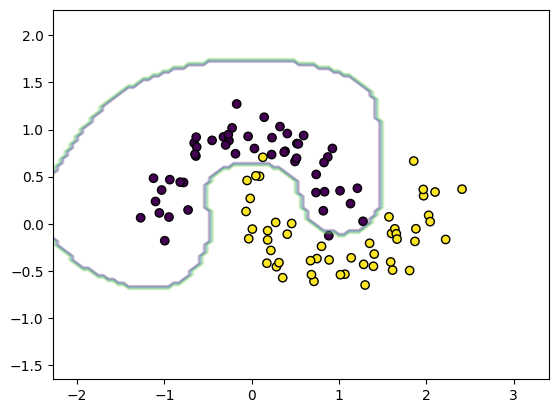

In [ ]:
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

rbf_model = make_pipeline(StandardScaler(), SVC(kernel="rbf", gamma=1, C=5))

rbf_model.fit(X, y)

plot_decision_boundary(rbf_model, X, y)



### Gamma Variation

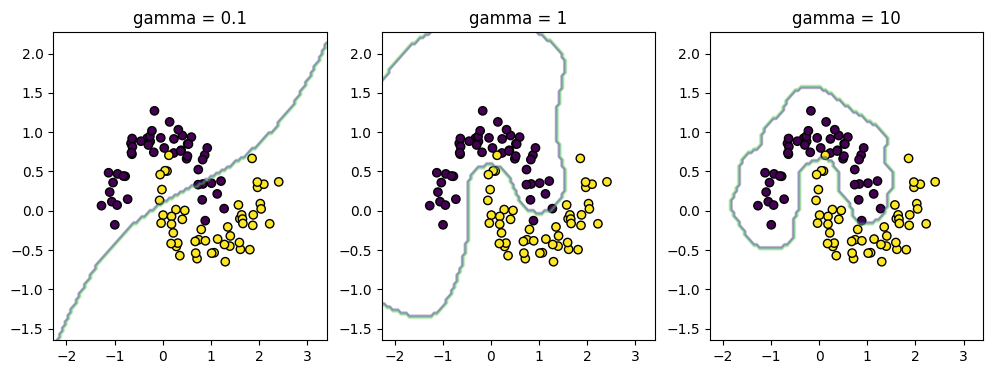

In [ ]:
# Gamma Test

gamma_values = [0.1, 1, 10]

plt.figure(figsize=(12,4))
for i, g in enumerate(gamma_values):
    model = make_pipeline(StandardScaler(),
                          SVC(kernel="rbf", gamma=g, C=1))
    model.fit(X_moons, y_moons)
    plt.subplot(1,3,i+1)
    plot_decision_boundary(model, X_moons, y_moons)
    plt.title(f"gamma = {g}")
plt.show()

## Kernel Comparison

Compare linear, polynomial, and RBF kernels

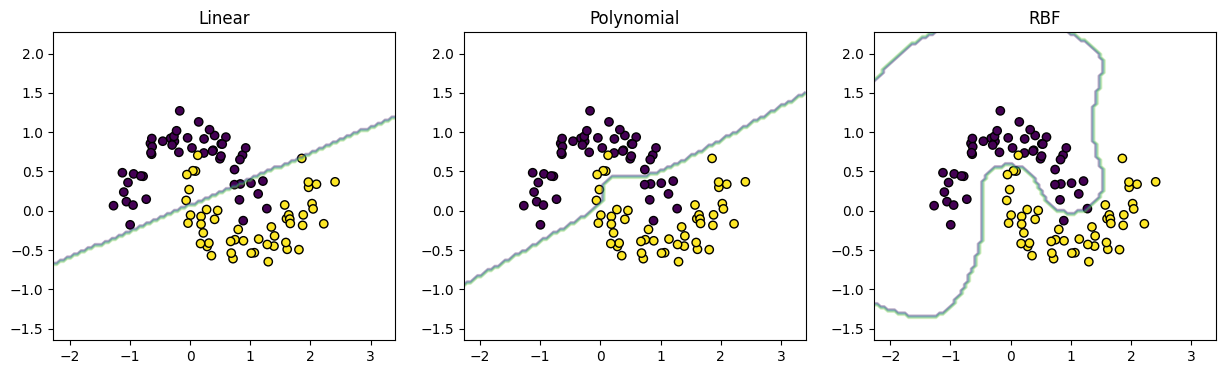

In [ ]:
models = {
    "Linear": make_pipeline(StandardScaler(), SVC(kernel="linear", C=1)),
    "Polynomial": make_pipeline(StandardScaler(), SVC(kernel="poly", degree=3, C=1)),
    "RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", gamma=1, C=1))
}

plt.figure(figsize=(15,4))
for i, (name, model) in enumerate(models.items()):
    model.fit(X, y)
    plt.subplot(1,3,i+1)
    plot_decision_boundary(model, X, y)
    plt.title(name)
plt.show()

###Linear Kernel
* Best Use: Data that is already linearly separable.
* When to Use: High-dimensional data, such as text classification, where the number of features is large (N < F)
* Performance: Fastest training and testing speeds; least complex, but often lower accuracy on complex data.
* Boundary: Straight line

###Polynomial Kernel
* Best Use: Data with mild curvature or polynomial relationships.
* When to Use: When you need a balance between linear simplicity and high complexity, typically with lower-degree polynomials.
* Performance: Generally slower than linear but can be highly accurate; requires a careful tuning of the degree.
* Boundary: Curvilinear boundary

###RBF Kernel
* Best Use: Complex, non-linear data with no clear linear separation.
* When to Use: General Purpose non-linear data
* Performance: Slower requiring tuning
* Boundary: Highly Flexible

# Hyperparameter Tuning

## GridSearchCV is used to find the best C and Gamma.

We do this to optimize performance, accuracy, and efficiency by finding the best config of parameters that aren't learned from the data. This prevents underfitting or overfitting as well as training time. This also ensures the model generalizes well to new unseen data.

In [ ]:
pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf"))

param_grid = {"svc__C":[0.1,1,10,100],
              "svc__gamma":[0.1,1,5,10]}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X, y)

print(grid.best_params_, grid.best_score_)

{'svc__C': 0.1, 'svc__gamma': 5} 0.97


# SVM Regression

In [ ]:
from sklearn.datasets import make_regression

# Linear Dataset
X_lin, y_lin = make_regression(n_samples=200, n_features=1, noise=10, random_state = 42)


In [ ]:
svm_reg = make_pipeline(StandardScaler(), LinearSVR(epsilon=0.5, random_state=42))

svm_reg.fit(X_lin, y_lin)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr', LinearSVR(epsilon=0.5, random_state=42))])

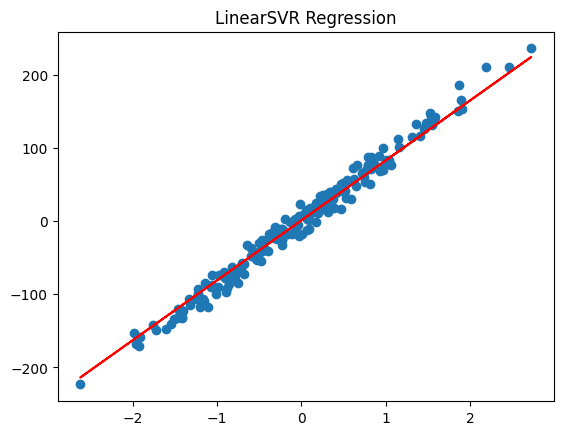

In [ ]:
# Visualization of Linear SVR

y_pred = svm_reg.predict(X_lin)

plt.scatter(X_lin, y_lin)
plt.plot(X_lin, y_pred, color='red')
plt.title("LinearSVR Regression")
plt.show()


In [ ]:
# Quadratic Dataset

np.random.seed(42) # Solution to Life, the Universe, and Everything
X_quad = np.sort(5 * np.random.rand(200, 1), axis=0)
y_quad = 0.5 * X_quad**2 + X_quad + 2 + np.random.randn(200,1)
y_quad = y_quad.ravel()

In [ ]:
# Polynomial SVR Model

In [ ]:
from sklearn.svm import SVR

svm_poly_reg = make_pipeline(StandardScaler(), SVR(kernel="poly", degree=2, C=100, gamma="scale", coef0=1, epsilon=0.1))
svm_poly_reg.fit(X_quad, y_quad)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=100, coef0=1, degree=2, kernel='poly'))])

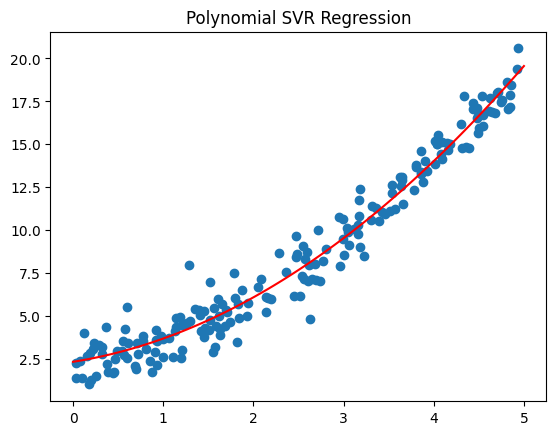

In [ ]:
# Visualization of Polynomial SVR

X_plot = np.linspace(0,5,100).reshape(-1,1)
y_pred_poly = svm_poly_reg.predict(X_plot)

plt.scatter(X_quad, y_quad)
plt.plot(X_plot, y_pred_poly, color="red")
plt.title("Polynomial SVR Regression")
plt.show()

# Although this plot fits well it actually very much underfit with the initial parameters of (degree=2,C=1,epsilon=0.1)